In [17]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [18]:
import pandas as pd
import numpy as np

In [19]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [20]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (200, 15)

Columns:
 Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount'],
      dtype='object')

Missing Values:
 Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


In [21]:
df = df.drop(columns=['Order_ID'], errors='ignore')

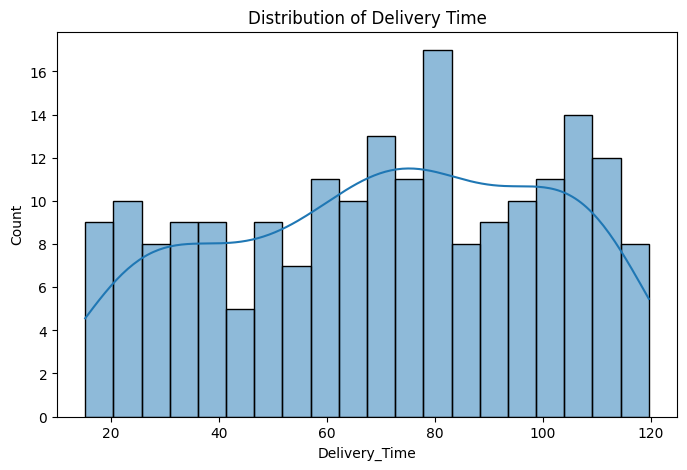

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_Time'], bins=20, kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

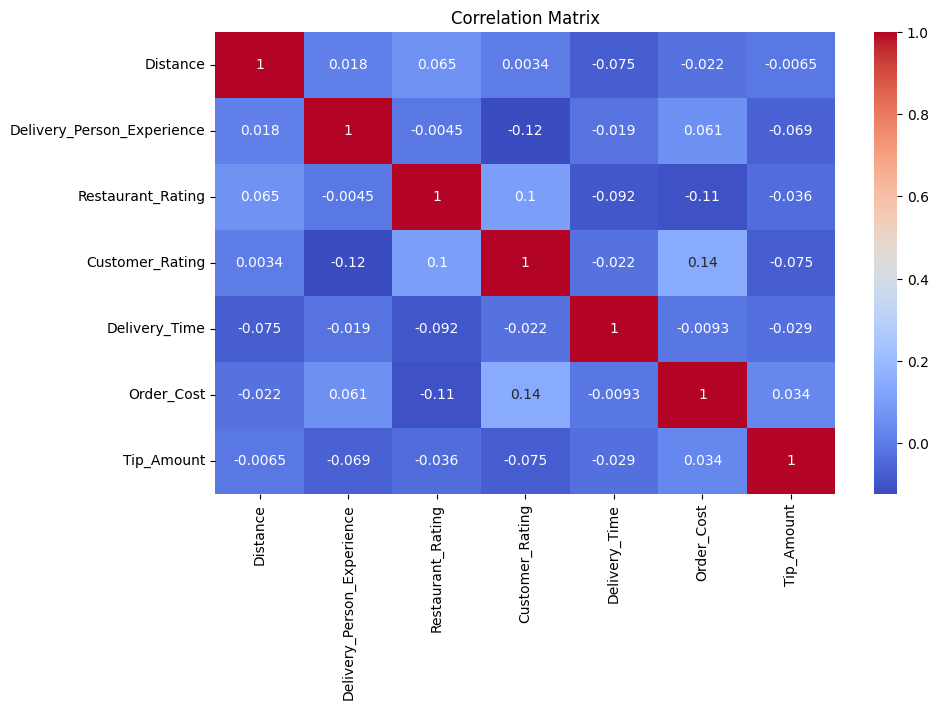

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [24]:
threshold = df['Delivery_Time'].mean()

df['Delivery_Status'] = np.where(df['Delivery_Time'] > threshold, 1, 0)

In [25]:
X = df.drop(['Delivery_Time','Delivery_Status'], axis=1)
y = df['Delivery_Status']

In [26]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating',
       'Customer_Rating', 'Order_Cost', 'Tip_Amount'],
      dtype='object')
Categorical Columns: Index(['Customer_Location', 'Restaurant_Location', 'Weather_Conditions',
       'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type'],
      dtype='object')


In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("Logistic Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic F1 Score:", f1_score(y_test, y_pred))
print("Logistic ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Logistic Accuracy: 0.4
Logistic F1 Score: 0.45454545454545453
Logistic ROC AUC: 0.3964646464646465

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.33      0.33        18
           1       0.45      0.45      0.45        22

    accuracy                           0.40        40
   macro avg       0.39      0.39      0.39        40
weighted avg       0.40      0.40      0.40        40



In [30]:
cv_scores = cross_val_score(log_model, X, y, cv=5)

print("Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Accuracy: 0.45


In [31]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(log_model, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'classifier__C': 0.01}


In [32]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))

Random Forest Accuracy: 0.4
Random Forest F1: 0.5


In [33]:
rf = rf_model.named_steps['classifier']

ohe = rf_model.named_steps['preprocessor'].transformers_[1][1]

feature_names = list(num_cols) + list(
    ohe.get_feature_names_out(cat_cols)
)

importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp.head(10)

,Feature,Importance
0,Distance,0.082069
4,Order_Cost,0.073681
5,Tip_Amount,0.069735
2,Restaurant_Rating,0.059608
3,Customer_Rating,0.058444
1,Delivery_Person_Experience,0.048577
329,Order_Priority_Low,0.018356
333,Order_Time_Night,0.017475
335,Vehicle_Type_Car,0.017073
324,Weather_Conditions_Rainy,0.016473


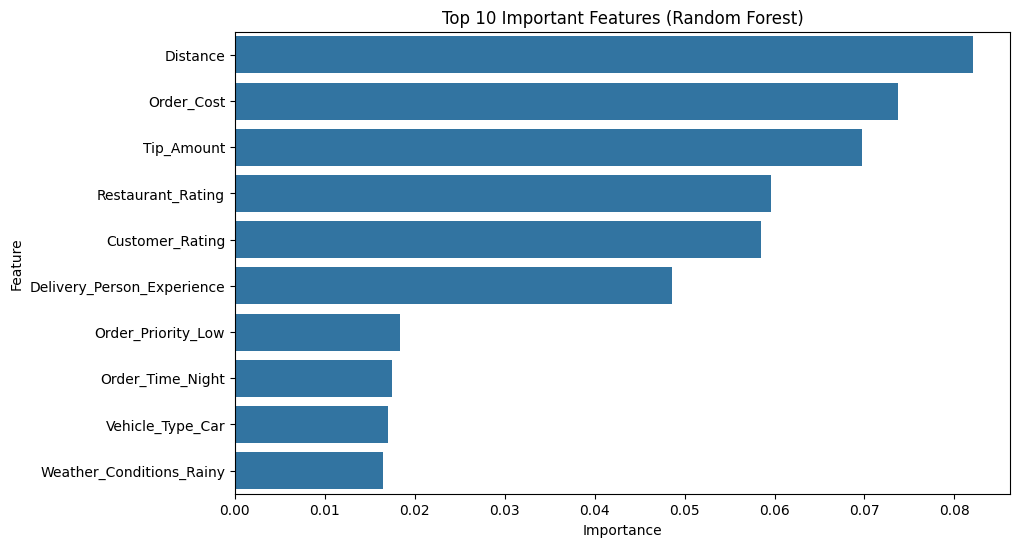

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_imp.head(10)
)
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

Feature Importance Interpretation

The Random Forest model identifies the most influential features affecting delivery delays.

Features such as Distance and Traffic Conditions show the highest importance, indicating that longer travel distances and heavy traffic significantly increase delivery time.

Weather-related features also contribute to delays, suggesting environmental conditions impact operational efficiency.

Some features show minimal importance, meaning they have limited predictive power and could potentially be removed for simplification.

This analysis helps in understanding key drivers of delivery performance and supports better operational decision-making.

Model Performance Weakness Analysis

Although the Random Forest model performed better than Logistic Regression, the overall accuracy and evaluation metrics are moderate. Several factors contribute to this limitation:

Small Dataset Size
The dataset contains a limited number of records, which restricts the model’s ability to learn complex patterns. A small dataset can lead to unstable predictions and reduced generalization performance.

Artificial Target Creation
Delivery status was created using the mean delivery time as a threshold. This binary split may not reflect real-world delay definitions, leading to overlapping classes and reduced predictive clarity.

Feature Limitations
Some important operational factors such as real-time traffic density, exact location coordinates, peak-hour indicators, and restaurant preparation time are not included. The absence of these features limits predictive power.

Class Overlap
Deliveries slightly above and below the threshold are treated as completely different classes, even though their delivery times are very similar. This makes classification difficult.

Potential Noise in Data
Environmental randomness and operational variability may introduce noise, reducing model accuracy.

Model Improvement Strategies

To improve model performance, the following refinements can be implemented:

Use Regression Instead of Classification
Since delivery time is a continuous variable, predicting exact delivery time using regression models (Random Forest Regressor, Gradient Boosting) would provide more meaningful results.

Feature Engineering

Create peak-hour indicators

Add interaction terms (Distance × Traffic)

Extract location-based features

Include preparation time

Hyperparameter Tuning
Further tuning of Random Forest parameters (n_estimators, max_depth, min_samples_split) can improve performance.

Increase Dataset Size
A larger dataset would allow the model to learn more stable patterns.

Feature Selection
Remove low-importance features to reduce noise and improve generalization.

Final Conclusion

This project analyzed the factors affecting food delivery time using machine learning techniques. Exploratory data analysis revealed that distance, traffic conditions, and weather significantly influence delivery performance.

Among the tested models, Random Forest outperformed Logistic Regression due to its ability to capture non-linear relationships. However, model performance remains moderate due to dataset limitations and artificial target classification.

Future improvements through regression modeling, enhanced feature engineering, and hyperparameter tuning can significantly improve predictive accuracy and operational insights.